In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"/content/train_and_test2.csv")

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [3]:
print("Shape:", df.shape)
print(df.columns)

Shape: (1309, 28)
Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')


In [4]:
df.columns = df.columns.str.strip()

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [7]:
print(df.columns.tolist())

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived', 'FamilySize']


In [9]:
df['FamilySize'] = df['sibsp'] + df['Parch'] + 1

In [10]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 19, 59, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

In [11]:
df[['Age', 'sibsp', 'Parch', 'FamilySize', 'AgeGroup']].head()

,Age,sibsp,Parch,FamilySize,AgeGroup
0,22.0,1,0,2,Adult
1,38.0,1,0,2,Adult
2,26.0,0,0,1,Adult
3,35.0,1,0,2,Adult
4,35.0,0,0,1,Adult


In [12]:
X = df.drop('2urvived', axis=1)
y = df['2urvived']

In [13]:
zero_columns = [col for col in X.columns if col.startswith('zero')]

X = X.drop(zero_columns, axis=1)

In [14]:
X = X.drop(['Passengerid'], axis=1, errors='ignore')

In [15]:
print(X.columns.tolist())

['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', 'FamilySize', 'AgeGroup']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1047, 9)
Testing data: (262, 9)


In [17]:
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', 'FamilySize']

Categorical Features:
['AgeGroup']


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Task 1 Baseline Accuracy:",
      round(baseline_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

Task 1 Baseline Accuracy: 75.95 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       194
           1       0.54      0.49      0.51        68

    accuracy                           0.76       262
   macro avg       0.68      0.67      0.68       262
weighted avg       0.75      0.76      0.76       262



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Task 1 Baseline Accuracy:",
      round(baseline_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

Task 1 Baseline Accuracy: 75.95 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       194
           1       0.54      0.49      0.51        68

    accuracy                           0.76       262
   macro avg       0.68      0.67      0.68       262
weighted avg       0.75      0.76      0.76       262



In [21]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid Search Completed!")

Grid Search Completed!


In [22]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [23]:
print("Best Cross-Validation Accuracy:",
      round(grid_search.best_score_ * 100, 2), "%")

Best Cross-Validation Accuracy: 80.04 %


In [24]:
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

print("Task 2 Tuned Accuracy:",
      round(tuned_accuracy * 100, 2), "%")

Task 2 Tuned Accuracy: 77.1 %


In [25]:
print("Task 2 Tuned Model Classification Report:")
print(classification_report(y_test, tuned_pred))

Task 2 Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       194
           1       0.58      0.44      0.50        68

    accuracy                           0.77       262
   macro avg       0.70      0.66      0.68       262
weighted avg       0.76      0.77      0.76       262



In [26]:
print("========== BEFORE vs AFTER ==========")

print("Task 1 Baseline Accuracy:",
      round(baseline_accuracy * 100, 2), "%")

print("Task 2 Tuned Accuracy:",
      round(tuned_accuracy * 100, 2), "%")

improvement = tuned_accuracy - baseline_accuracy

print("Improvement:",
      round(improvement * 100, 2),
      "percentage points")

========== BEFORE vs AFTER ==========
Task 1 Baseline Accuracy: 75.95 %
Task 2 Tuned Accuracy: 77.1 %
Improvement: 1.15 percentage points


In [27]:
comparison = pd.DataFrame({
    'Model': [
        'Task 1 Baseline Random Forest',
        'Task 2 Tuned Random Forest'
    ],
    'Accuracy': [
        baseline_accuracy,
        tuned_accuracy
    ]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,Task 1 Baseline Random Forest,0.759542,75.954198
1,Task 2 Tuned Random Forest,0.770992,77.099237


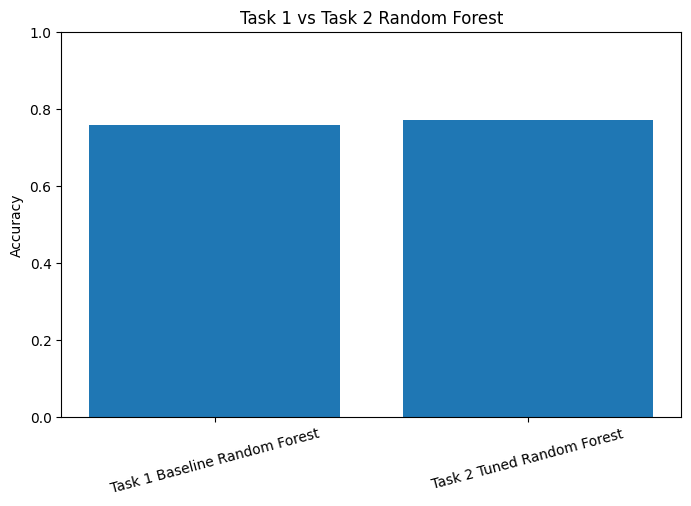

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Task 1 vs Task 2 Random Forest')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

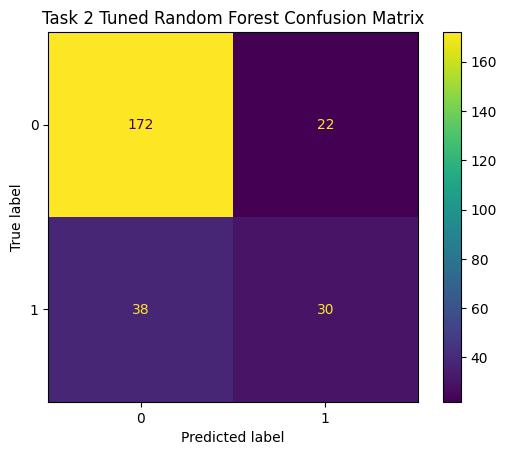

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Task 2 Tuned Random Forest Confusion Matrix")
plt.show()